In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

# CWD = d:\sem-6\AI-ML\week7  (notebook folder)
_DATASET_ROOT = os.path.join("..", "datasets", "DevanagariHandwrittenDigitDataset")

train_dir = os.path.join(_DATASET_ROOT, "Train")
test_dir  = os.path.join(_DATASET_ROOT, "Test")

IMG_HEIGHT, IMG_WIDTH = 32, 32
NUM_CLASSES = 10
CLASS_NAMES = [f"digit_{i}" for i in range(NUM_CLASSES)]

print("Libraries loaded.")
print(f"Train dir : {os.path.abspath(train_dir)}")
print(f"  Exists  : {os.path.isdir(train_dir)}")
print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}")

Libraries loaded.
Train dir : d:\sem-6\AI-ML\datasets\DevanagariHandwrittenDigitDataset\Train
  Exists  : True
Image size: 32x32


## Step 1 — Load the Devanagari Dataset using PIL

Loading training images …
  Loaded 17000 images | shape: (17000, 32, 32)
  Pixel value range (raw): [0, 255]
  Labels : [0 1 2 3 4 5 6 7 8 9]  (classes: 10)


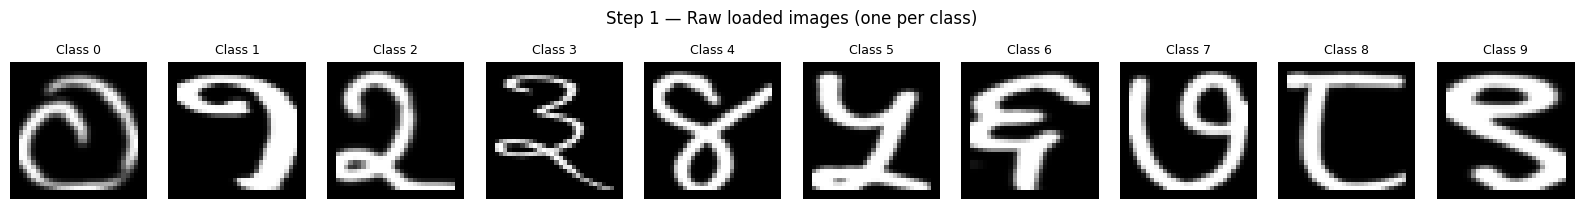

In [9]:
def load_dataset(base_dir):
    """Load all images from class subdirectories using PIL."""
    images, labels = [], []
    for label, class_name in enumerate(CLASS_NAMES):
        class_path = os.path.join(base_dir, class_name)
        for fname in os.listdir(class_path):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                img = Image.open(os.path.join(class_path, fname)).convert("L")
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                images.append(np.array(img))
                labels.append(label)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

print("Loading training images …")
X_raw, y_raw = load_dataset(train_dir)
print(f"  Loaded {len(X_raw)} images | shape: {X_raw.shape}")
print(f"  Pixel value range (raw): [{X_raw.min():.0f}, {X_raw.max():.0f}]")
print(f"  Labels : {np.unique(y_raw)}  (classes: {NUM_CLASSES})")

# Visualise one sample per class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 2))
for cls in range(NUM_CLASSES):
    idx = np.where(y_raw == cls)[0][0]
    axes[cls].imshow(X_raw[idx], cmap="gray")
    axes[cls].set_title(f"Class {cls}", fontsize=9)
    axes[cls].axis("off")
plt.suptitle("Step 1 — Raw loaded images (one per class)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Step 2 — Normalize Images to [0, 1]

Pixel range after normalisation: [0.0000, 1.0000]
Mean: 0.2423  |  Std: 0.3887


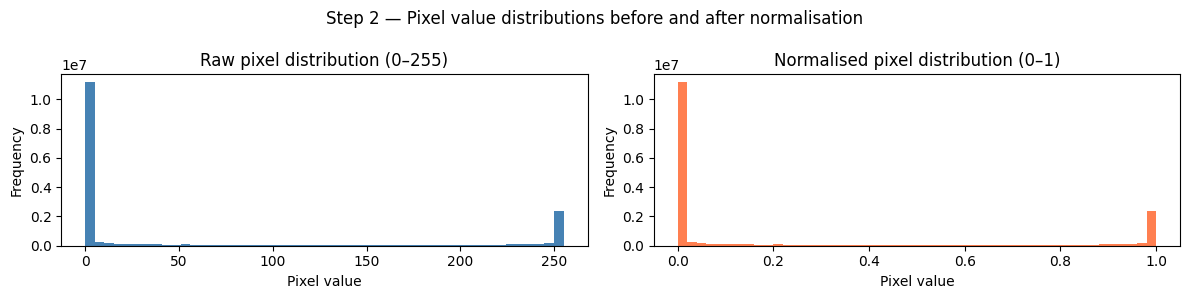

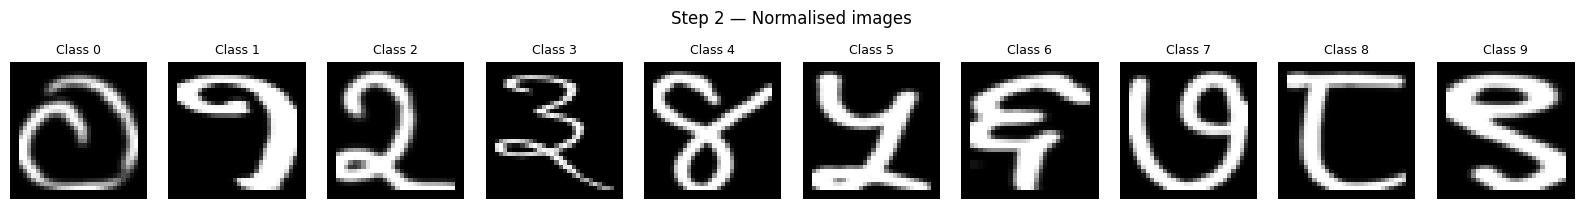

In [10]:
X_norm = X_raw / 255.0

print(f"Pixel range after normalisation: [{X_norm.min():.4f}, {X_norm.max():.4f}]")
print(f"Mean: {X_norm.mean():.4f}  |  Std: {X_norm.std():.4f}")

# Side-by-side: raw vs normalised pixel value histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(X_raw.ravel(), bins=50, color="steelblue", edgecolor="none")
axes[0].set_title("Raw pixel distribution (0–255)")
axes[0].set_xlabel("Pixel value")
axes[0].set_ylabel("Frequency")

axes[1].hist(X_norm.ravel(), bins=50, color="coral", edgecolor="none")
axes[1].set_title("Normalised pixel distribution (0–1)")
axes[1].set_xlabel("Pixel value")
axes[1].set_ylabel("Frequency")

plt.suptitle("Step 2 — Pixel value distributions before and after normalisation", fontsize=12)
plt.tight_layout()
plt.show()

# Also show the same sample images after normalisation
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 2))
for cls in range(NUM_CLASSES):
    idx = np.where(y_raw == cls)[0][0]
    axes[cls].imshow(X_norm[idx], cmap="gray", vmin=0, vmax=1)
    axes[cls].set_title(f"Class {cls}", fontsize=9)
    axes[cls].axis("off")
plt.suptitle("Step 2 — Normalised images", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Step 3 — Reshape to Include Channel Dimension (Keras Compatibility)

Shape before reshape : (17000, 32, 32)  (N, H, W)
Shape after  reshape : (17000, 32, 32, 1)  (N, H, W, C=1)
dtype : float32


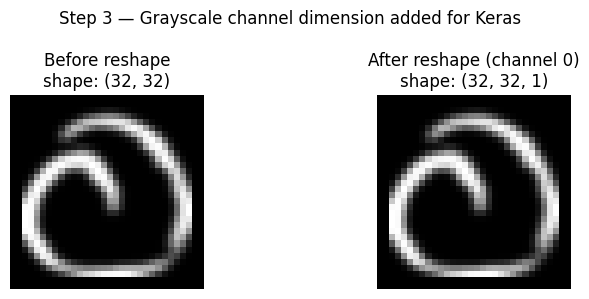

In [11]:
# Add a trailing channel dimension: (N, H, W) -> (N, H, W, 1)
X = X_norm[..., np.newaxis]

print(f"Shape before reshape : {X_norm.shape}  (N, H, W)")
print(f"Shape after  reshape : {X.shape}  (N, H, W, C=1)")
print(f"dtype : {X.dtype}")

# Visualise the channel structure with a single image
sample = X[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(X_norm[0], cmap="gray")
axes[0].set_title(f"Before reshape\nshape: {X_norm[0].shape}")
axes[0].axis("off")

axes[1].imshow(sample[:, :, 0], cmap="gray")
axes[1].set_title(f"After reshape (channel 0)\nshape: {sample.shape}")
axes[1].axis("off")

plt.suptitle("Step 3 — Grayscale channel dimension added for Keras", fontsize=12)
plt.tight_layout()
plt.show()

## Step 4 — Split into Training and Validation Sets

Total samples   : 17000
Training set    : (13600, 32, 32, 1)  (13600 images)
Validation set  : (3400, 32, 32, 1)  (3400 images)
Split ratio     : 80% / 20%


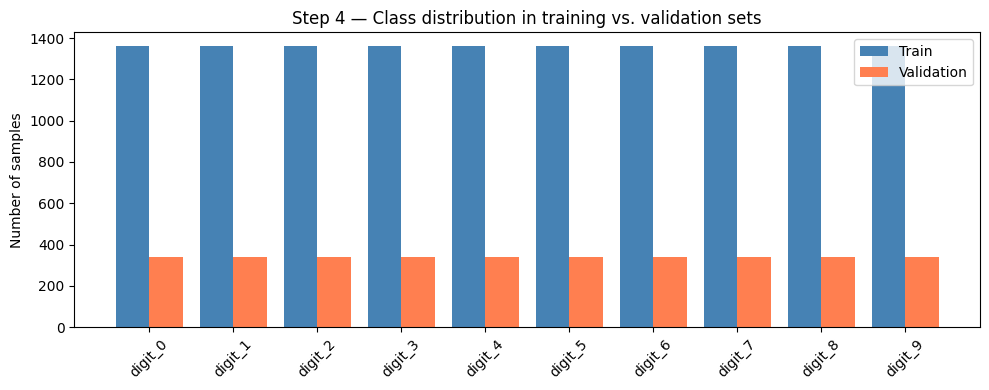

In [12]:
VALIDATION_SPLIT = 0.2
RANDOM_SEED = 42

X_train, X_val, y_train, y_val = train_test_split(
    X, y_raw,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_SEED,
    stratify=y_raw
)

print(f"Total samples   : {len(X)}")
print(f"Training set    : {X_train.shape}  ({len(X_train)} images)")
print(f"Validation set  : {X_val.shape}  ({len(X_val)} images)")
print(f"Split ratio     : {1 - VALIDATION_SPLIT:.0%} / {VALIDATION_SPLIT:.0%}")

# Class distribution bar chart
train_counts = [np.sum(y_train == c) for c in range(NUM_CLASSES)]
val_counts   = [np.sum(y_val   == c) for c in range(NUM_CLASSES)]
x_pos = np.arange(NUM_CLASSES)
width = 0.4

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_pos - width / 2, train_counts, width, label="Train",      color="steelblue")
ax.bar(x_pos + width / 2, val_counts,   width, label="Validation", color="coral")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"digit_{i}" for i in range(NUM_CLASSES)], rotation=45)
ax.set_ylabel("Number of samples")
ax.set_title("Step 4 — Class distribution in training vs. validation sets")
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — Add Noise for Denoising Purposes

Two noise types are demonstrated:  
- **Gaussian noise** — adds normally-distributed random values (σ controls strength)  
- **Salt-and-pepper noise** — randomly sets pixels to 0 (pepper) or 1 (salt)

Gaussian noise (σ=0.15) — pixel range: [0.0000, 1.0000]
Salt-pepper    (p=0.05)      — pixel range: [0.0000, 1.0000]


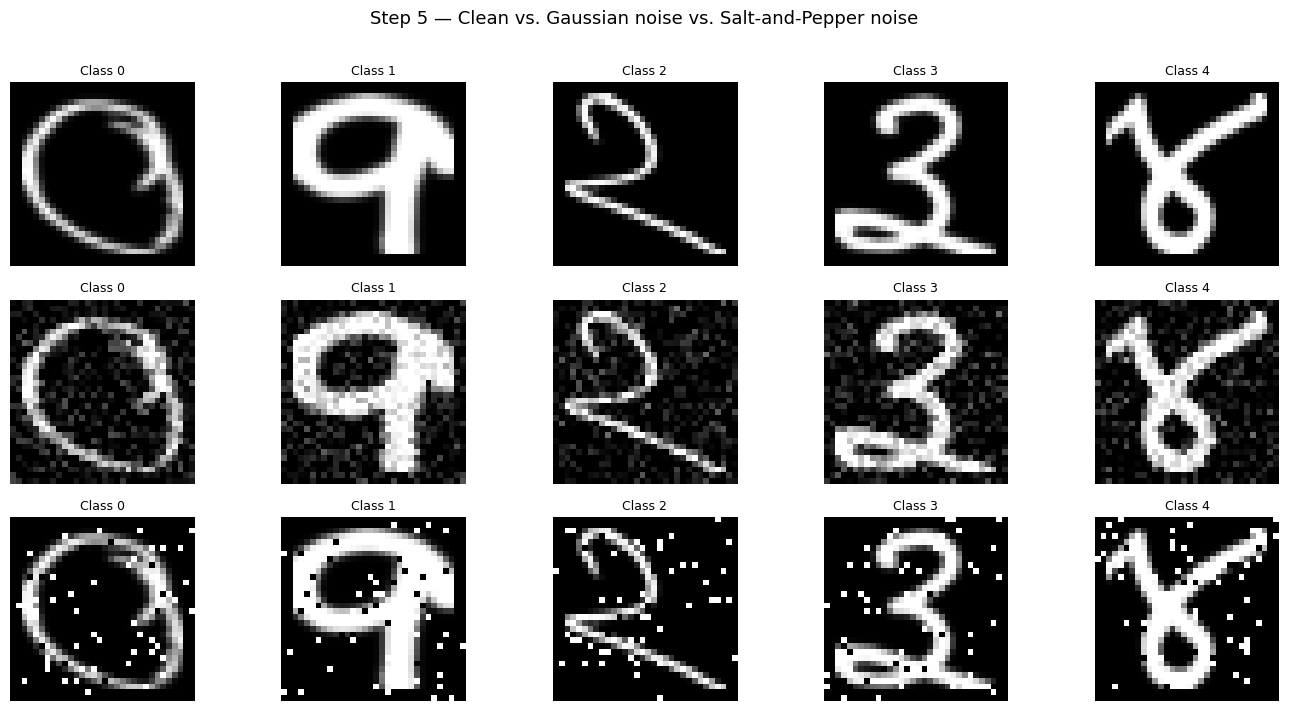

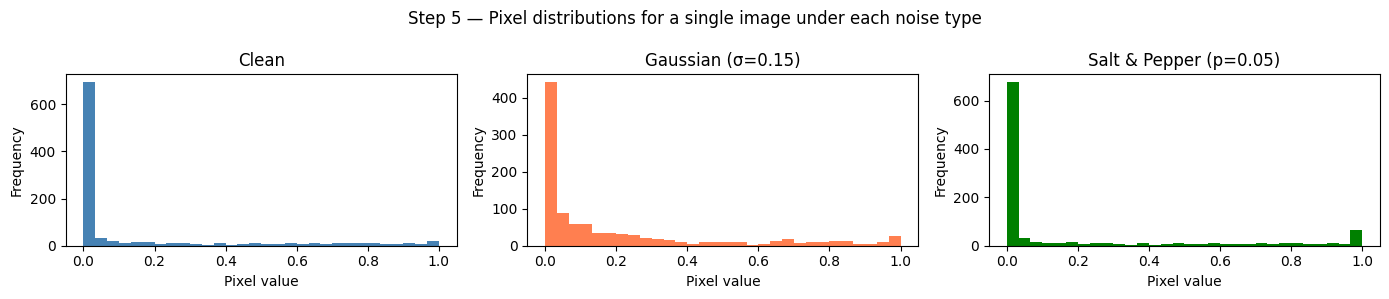

In [13]:
def add_gaussian_noise(images, sigma=0.15, seed=42):
    """Add Gaussian noise and clip to [0, 1]."""
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=sigma, size=images.shape).astype(np.float32)
    return np.clip(images + noise, 0.0, 1.0)

def add_salt_pepper_noise(images, amount=0.05, seed=42):
    """Randomly set `amount` fraction of pixels to 0 (pepper) or 1 (salt)."""
    rng = np.random.default_rng(seed)
    noisy = images.copy()
    n_pixels = images.shape[1] * images.shape[2]  # H * W
    n_corrupt = int(amount * n_pixels)
    for i in range(len(noisy)):
        # Salt
        coords = rng.integers(0, images.shape[1], size=(n_corrupt, 2))
        noisy[i, coords[:, 0], coords[:, 1], 0] = 1.0
        # Pepper
        coords = rng.integers(0, images.shape[1], size=(n_corrupt, 2))
        noisy[i, coords[:, 0], coords[:, 1], 0] = 0.0
    return noisy

# Apply both noise types to the training set
GAUSSIAN_SIGMA = 0.15
SP_AMOUNT      = 0.05

X_train_gaussian = add_gaussian_noise(X_train, sigma=GAUSSIAN_SIGMA)
X_train_sp       = add_salt_pepper_noise(X_train, amount=SP_AMOUNT)

print(f"Gaussian noise (σ={GAUSSIAN_SIGMA}) — pixel range: [{X_train_gaussian.min():.4f}, {X_train_gaussian.max():.4f}]")
print(f"Salt-pepper    (p={SP_AMOUNT})      — pixel range: [{X_train_sp.min():.4f}, {X_train_sp.max():.4f}]")

# Visualisation: clean vs. Gaussian vs. salt-and-pepper (5 samples)
N_SHOW = 5
samples_idx = [np.where(y_train == c)[0][0] for c in range(N_SHOW)]

fig, axes = plt.subplots(3, N_SHOW, figsize=(14, 7))
row_labels = ["Clean", f"Gaussian (σ={GAUSSIAN_SIGMA})", f"Salt & Pepper (p={SP_AMOUNT})"]

for col, idx in enumerate(samples_idx):
    for row, (data, title) in enumerate([
        (X_train,          "Clean"),
        (X_train_gaussian, f"Gaussian σ={GAUSSIAN_SIGMA}"),
        (X_train_sp,       f"S&P p={SP_AMOUNT}"),
    ]):
        axes[row, col].imshow(data[idx, :, :, 0], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(row_labels[row], fontsize=10, labelpad=6)
        axes[row, col].set_title(f"Class {y_train[idx]}", fontsize=9)

plt.suptitle("Step 5 — Clean vs. Gaussian noise vs. Salt-and-Pepper noise", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Pixel-value histogram comparison for one image
idx0 = samples_idx[0]
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, data, label, color in zip(
    axes,
    [X_train[idx0], X_train_gaussian[idx0], X_train_sp[idx0]],
    ["Clean", f"Gaussian (σ={GAUSSIAN_SIGMA})", f"Salt & Pepper (p={SP_AMOUNT})"],
    ["steelblue", "coral", "green"]
):
    ax.hist(data.ravel(), bins=30, color=color, edgecolor="none")
    ax.set_title(label)
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Frequency")
plt.suptitle("Step 5 — Pixel distributions for a single image under each noise type", fontsize=12)
plt.tight_layout()
plt.show()

## Step 2 — Build the Denoising Convolutional Autoencoder

Architecture overview:

| Block | Layer | Filters | Kernel | Activation |
|-------|-------|---------|--------|------------|
| **Encoder** | Conv2D | 32 | 3×3 | ReLU |
| | MaxPool2D | — | 2×2 | — |
| | Conv2D | 64 | 3×3 | ReLU |
| | MaxPool2D | — | 2×2 | — |
| **Decoder** | Conv2DTranspose | 64 | 3×3 | ReLU |
| | UpSampling2D | — | 2×2 | — |
| | Conv2DTranspose | 32 | 3×3 | ReLU |
| | UpSampling2D | — | 2×2 | — |
| **Output** | Conv2D | 1 | 3×3 | Sigmoid |

In [14]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D
)

def build_autoencoder(input_shape=(32, 32, 1), base_filters=32):
    """
    4-layer Convolutional Autoencoder (2 encoder + 2 decoder conv blocks).
    Encoder: Conv → MaxPool → Conv → MaxPool
    Decoder: ConvTranspose → UpSample → ConvTranspose → UpSample → Conv (output)
    """
    inp = Input(shape=input_shape, name="input")

    # ── Encoder ──────────────────────────────────────────────────────────────
    x = Conv2D(base_filters,     3, activation="relu", padding="same", name="enc_conv1")(inp)
    x = MaxPooling2D(2,          padding="same", name="enc_pool1")(x)
    x = Conv2D(base_filters * 2, 3, activation="relu", padding="same", name="enc_conv2")(x)
    x = MaxPooling2D(2,          padding="same", name="enc_pool2")(x)   # ← latent space

    # ── Decoder ──────────────────────────────────────────────────────────────
    x = Conv2DTranspose(base_filters * 2, 3, activation="relu", padding="same", name="dec_conv1")(x)
    x = UpSampling2D(2, name="dec_up1")(x)
    x = Conv2DTranspose(base_filters,     3, activation="relu", padding="same", name="dec_conv2")(x)
    x = UpSampling2D(2, name="dec_up2")(x)

    # ── Output ───────────────────────────────────────────────────────────────
    out = Conv2D(1, 3, activation="sigmoid", padding="same", name="output")(x)

    model = Model(inp, out, name="denoising_autoencoder")
    return model

autoencoder = build_autoencoder(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), base_filters=32)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# Parameter count
total_params = autoencoder.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 74,497


## Step 3 — Train the Denoising Autoencoder

- **Input** : noisy images (Gaussian noise, σ = 0.15)  
- **Target** : original clean images  
- **Loss** : Mean Squared Error (MSE)  
- **Optimizer** : Adam  
- **Early stopping** monitors `val_loss` with patience = 5

Training for up to 50 epochs  |  batch size: 64
Input  (noisy)  : (13600, 32, 32, 1)
Target (clean)  : (13600, 32, 32, 1)

Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0260 - val_loss: 0.0077
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0065 - val_loss: 0.0058
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0051 - val_loss: 0.0051
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0045 - val_loss: 0.0042
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 9/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 10/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch

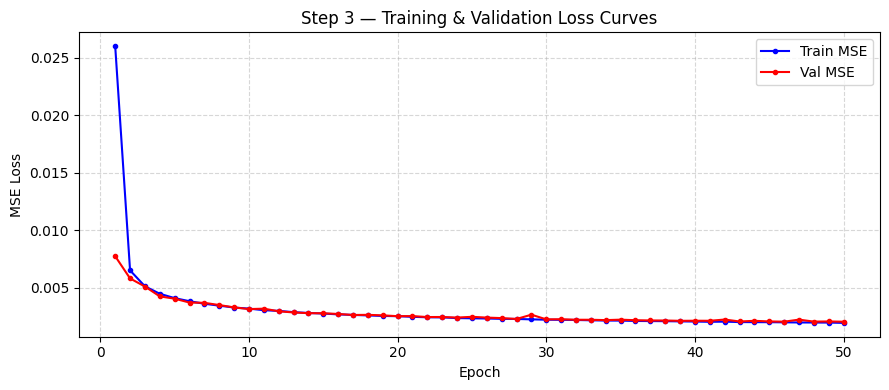


Best validation MSE : 0.002039  (epoch 50)
Total epochs run    : 50


In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS    = 50
BATCH_SIZE = 64

# Validation counterpart: also add the same noise to the validation set
X_val_gaussian = add_gaussian_noise(X_val, sigma=GAUSSIAN_SIGMA, seed=0)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_denoising_ae.keras", monitor="val_loss",
                    save_best_only=True, verbose=0),
]

print(f"Training for up to {EPOCHS} epochs  |  batch size: {BATCH_SIZE}")
print(f"Input  (noisy)  : {X_train_gaussian.shape}")
print(f"Target (clean)  : {X_train.shape}")
print()

history = autoencoder.fit(
    X_train_gaussian, X_train,          # noisy input → clean target
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_gaussian, X_val),
    callbacks=callbacks,
    verbose=1,
)

# ── Loss curves ──────────────────────────────────────────────────────────────
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
epochs_ran = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_ran, train_loss, "b-o", markersize=3, label="Train MSE")
ax.plot(epochs_ran, val_loss,   "r-o", markersize=3, label="Val MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Step 3 — Training & Validation Loss Curves")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

best_val = min(val_loss)
print(f"\nBest validation MSE : {best_val:.6f}  (epoch {val_loss.index(best_val) + 1})")
print(f"Total epochs run    : {len(train_loss)}")

## Step 4 — Evaluate and Visualize the Results

For each sample we display three rows: **Noisy input → Denoised output → Clean original**.

Validation MSE  : 0.002039
PSNR (noisy)    : 18.97 dB
PSNR (denoised) : 26.91 dB  ← improvement: +7.93 dB


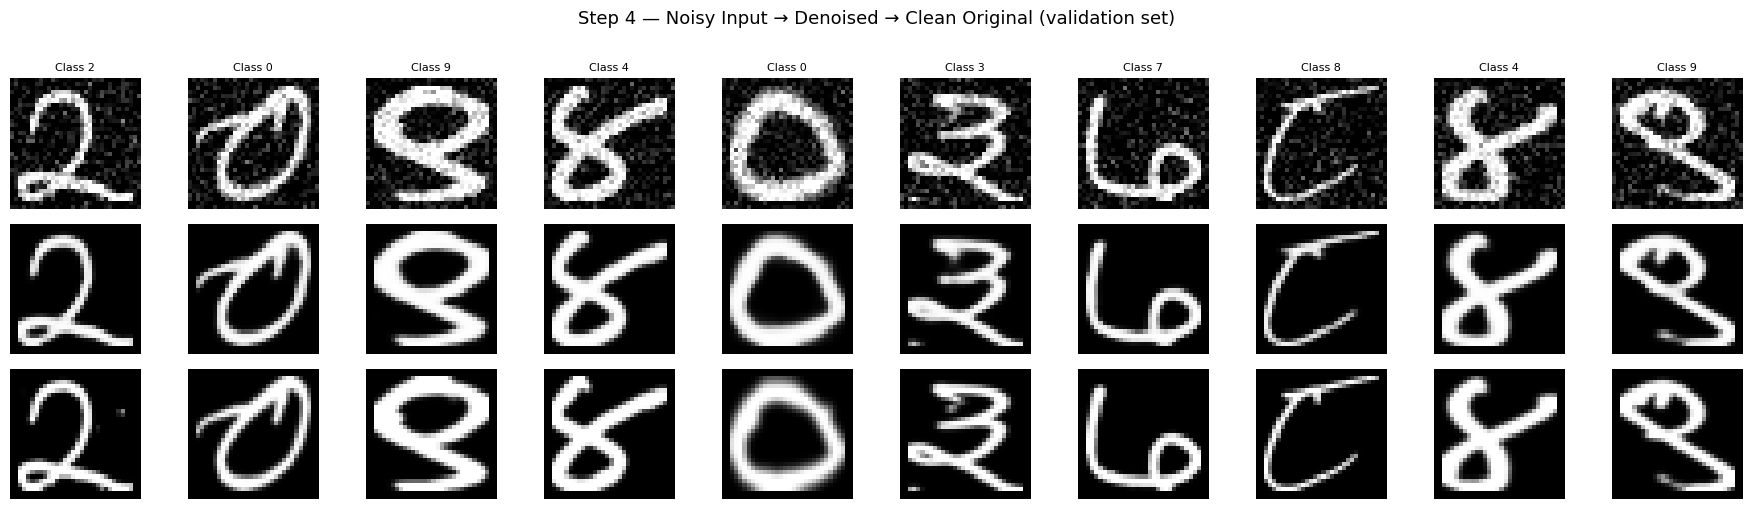

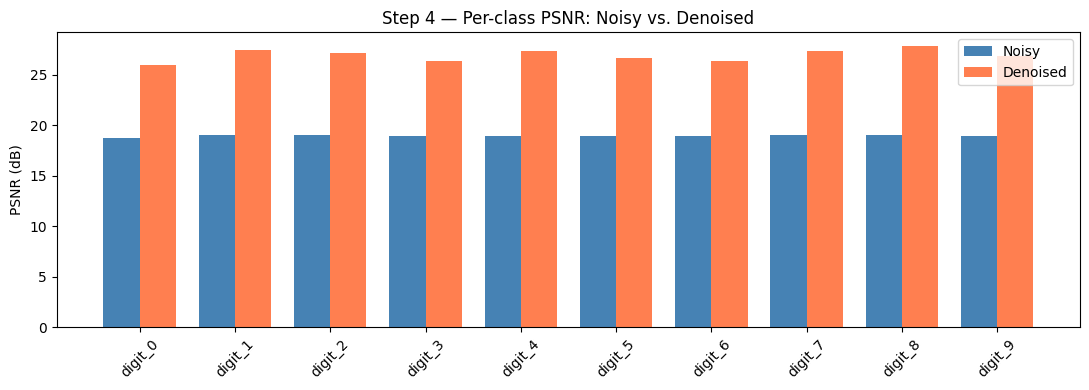

In [16]:
import math

# ── Quantitative evaluation ──────────────────────────────────────────────────
val_mse = autoencoder.evaluate(X_val_gaussian, X_val, verbose=0)
print(f"Validation MSE  : {val_mse:.6f}")

# Peak Signal-to-Noise Ratio  PSNR = 10 * log10(MAX^2 / MSE)
psnr_noisy    = 10 * math.log10(1.0 / np.mean((X_val_gaussian - X_val) ** 2))
X_val_denoised = autoencoder.predict(X_val_gaussian, verbose=0)
psnr_denoised  = 10 * math.log10(1.0 / np.mean((X_val_denoised  - X_val) ** 2))
print(f"PSNR (noisy)    : {psnr_noisy:.2f} dB")
print(f"PSNR (denoised) : {psnr_denoised:.2f} dB  ← improvement: {psnr_denoised - psnr_noisy:+.2f} dB")

# ── Visual comparison: 10 random validation samples ─────────────────────────
N_VIS = 10
rng_vis = np.random.default_rng(7)
vis_idx = rng_vis.choice(len(X_val), size=N_VIS, replace=False)

fig, axes = plt.subplots(3, N_VIS, figsize=(18, 5))
row_titles = ["Noisy Input", "Denoised (model)", "Clean Original"]

for col, i in enumerate(vis_idx):
    noisy    = X_val_gaussian[i, :, :, 0]
    denoised = X_val_denoised[i, :, :, 0]
    clean    = X_val[i, :, :, 0]

    for row, (img, cmap_lim) in enumerate([(noisy, (0, 1)),
                                            (denoised, (0, 1)),
                                            (clean, (0, 1))]):
        axes[row, col].imshow(img, cmap="gray", vmin=cmap_lim[0], vmax=cmap_lim[1])
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(row_titles[row], fontsize=10, labelpad=6)
    axes[0, col].set_title(f"Class {y_val[i]}", fontsize=8)

plt.suptitle("Step 4 — Noisy Input → Denoised → Clean Original (validation set)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Per-class PSNR bar chart ─────────────────────────────────────────────────
class_psnr_noisy    = []
class_psnr_denoised = []
for c in range(NUM_CLASSES):
    mask = y_val == c
    n_mse = np.mean((X_val_gaussian[mask] - X_val[mask]) ** 2)
    d_mse = np.mean((X_val_denoised[mask]  - X_val[mask]) ** 2)
    class_psnr_noisy.append(10 * math.log10(1.0 / n_mse))
    class_psnr_denoised.append(10 * math.log10(1.0 / d_mse))

x_pos = np.arange(NUM_CLASSES)
w = 0.38
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x_pos - w / 2, class_psnr_noisy,    w, label="Noisy",    color="steelblue")
ax.bar(x_pos + w / 2, class_psnr_denoised, w, label="Denoised", color="coral")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"digit_{i}" for i in range(NUM_CLASSES)], rotation=45)
ax.set_ylabel("PSNR (dB)")
ax.set_title("Step 4 — Per-class PSNR: Noisy vs. Denoised")
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — Experiment and Fine-Tune the Model

We sweep **3 dimensions** independently and record validation MSE + PSNR:

| Experiment | What changes |
|---|---|
| **A — Architecture depth** | shallow (1-conv) vs. baseline (2-conv) vs. deep (3-conv) |
| **B — Filter width** | base_filters = 16 / 32 / 64 |
| **C — Noise level** | σ = 0.05 / 0.15 / 0.30 |

In [17]:
# ── Helper: build autoencoders of varying depth ──────────────────────────────
def build_autoencoder_depth(depth=2, base_filters=32, input_shape=(32, 32, 1)):
    """
    depth=1 → 1 encoder conv + 1 decoder conv  (shallow)
    depth=2 → 2 + 2  (baseline)
    depth=3 → 3 + 3  (deep)
    """
    inp = Input(shape=input_shape, name="input")
    x = inp

    # Encoder
    for d in range(depth):
        filters = base_filters * (2 ** d)
        x = Conv2D(filters, 3, activation="relu", padding="same")(x)
        x = MaxPooling2D(2, padding="same")(x)

    # Decoder
    for d in reversed(range(depth)):
        filters = base_filters * (2 ** d)
        x = Conv2DTranspose(filters, 3, activation="relu", padding="same")(x)
        x = UpSampling2D(2)(x)

    out = Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="mse")
    return model

def quick_train(model, X_noisy_tr, X_clean_tr, X_noisy_val, X_clean_val,
                epochs=20, batch_size=64):
    """Train without verbose output and return best val MSE + PSNR."""
    cb = EarlyStopping(monitor="val_loss", patience=4,
                       restore_best_weights=True, verbose=0)
    h = model.fit(
        X_noisy_tr, X_clean_tr,
        epochs=epochs, batch_size=batch_size,
        validation_data=(X_noisy_val, X_clean_val),
        callbacks=[cb], verbose=0,
    )
    best_mse  = min(h.history["val_loss"])
    pred      = model.predict(X_noisy_val, verbose=0)
    best_psnr = 10 * math.log10(1.0 / np.mean((pred - X_clean_val) ** 2))
    return best_mse, best_psnr, h.history["loss"], h.history["val_loss"]

QUICK_EPOCHS = 20

# ── Experiment A — Architecture Depth ────────────────────────────────────────
print("=== Experiment A: Architecture Depth ===")
depth_results = {}
for depth in [1, 2, 3]:
    tf.keras.backend.clear_session()
    m   = build_autoencoder_depth(depth=depth, base_filters=32,
                                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 1))
    mse, psnr, tl, vl = quick_train(m, X_train_gaussian, X_train,
                                     X_val_gaussian, X_val, epochs=QUICK_EPOCHS)
    depth_results[f"depth={depth}"] = {"mse": mse, "psnr": psnr,
                                        "train_loss": tl, "val_loss": vl,
                                        "params": m.count_params()}
    print(f"  depth={depth}  params={m.count_params():>8,}  val_MSE={mse:.5f}  PSNR={psnr:.2f} dB")

# ── Experiment B — Filter Width ───────────────────────────────────────────────
print("\n=== Experiment B: Filter Width (base_filters) ===")
filter_results = {}
for bf in [16, 32, 64]:
    tf.keras.backend.clear_session()
    m   = build_autoencoder_depth(depth=2, base_filters=bf,
                                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 1))
    mse, psnr, tl, vl = quick_train(m, X_train_gaussian, X_train,
                                     X_val_gaussian, X_val, epochs=QUICK_EPOCHS)
    filter_results[f"filters={bf}"] = {"mse": mse, "psnr": psnr,
                                        "train_loss": tl, "val_loss": vl,
                                        "params": m.count_params()}
    print(f"  filters={bf:>2}  params={m.count_params():>8,}  val_MSE={mse:.5f}  PSNR={psnr:.2f} dB")

# ── Experiment C — Noise Level ────────────────────────────────────────────────
print("\n=== Experiment C: Noise Level (σ) ===")
noise_results = {}
for sigma in [0.05, 0.15, 0.30]:
    X_tr_n = add_gaussian_noise(X_train, sigma=sigma, seed=42)
    X_val_n = add_gaussian_noise(X_val,   sigma=sigma, seed=0)
    tf.keras.backend.clear_session()
    m   = build_autoencoder_depth(depth=2, base_filters=32,
                                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 1))
    mse, psnr, tl, vl = quick_train(m, X_tr_n, X_train, X_val_n, X_val,
                                     epochs=QUICK_EPOCHS)
    noise_results[f"σ={sigma}"] = {"mse": mse, "psnr": psnr,
                                    "train_loss": tl, "val_loss": vl}
    print(f"  σ={sigma}  val_MSE={mse:.5f}  PSNR={psnr:.2f} dB")[]

=== Experiment A: Architecture Depth ===

  depth=1  params=   9,857  val_MSE=0.00211  PSNR=26.76 dB
  depth=2  params=  74,497  val_MSE=0.00248  PSNR=26.06 dB
  depth=3  params= 332,801  val_MSE=0.00423  PSNR=23.73 dB

=== Experiment B: Filter Width (base_filters) ===
  filters=16  params=  18,817  val_MSE=0.00363  PSNR=24.40 dB
  filters=32  params=  74,497  val_MSE=0.00250  PSNR=26.03 dB
  filters=64  params= 296,449  val_MSE=0.00211  PSNR=26.75 dB

=== Experiment C: Noise Level (σ) ===
  σ=0.05  val_MSE=0.00127  PSNR=28.96 dB
  σ=0.15  val_MSE=0.00246  PSNR=26.09 dB
  σ=0.3  val_MSE=0.00526  PSNR=22.79 dB


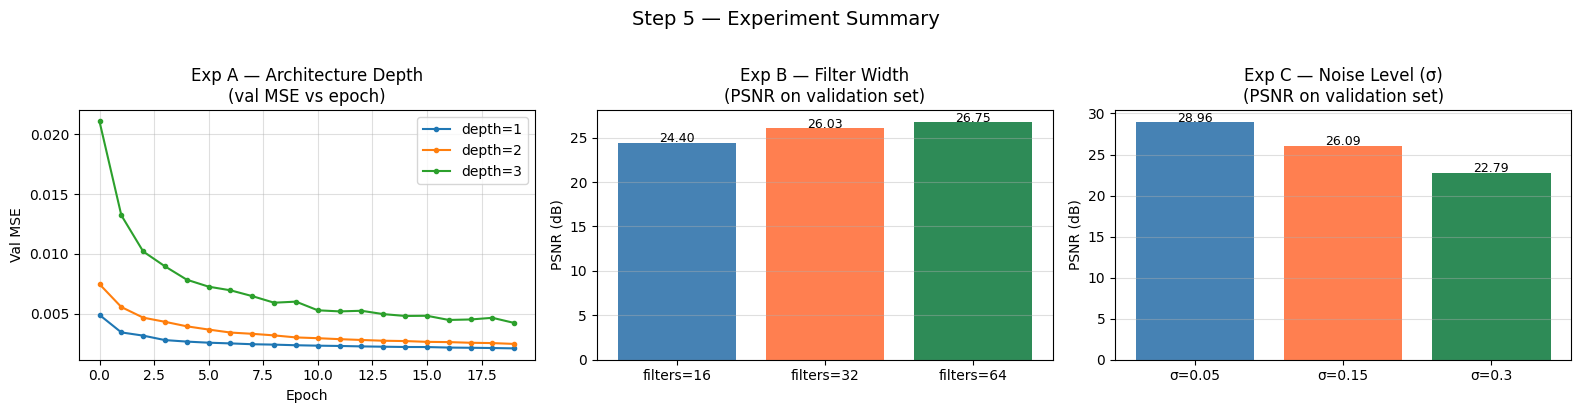


──────── Summary Table ────────────────────────────────────────────────
Experiment              val_MSE    PSNR (dB)     Params
──────────────────────────────────────────────────────────
depth=1                 0.00211        26.76      9,857
depth=2                 0.00248        26.06     74,497
depth=3                 0.00423        23.73    332,801
filters=16              0.00363        24.40     18,817
filters=32              0.00250        26.03     74,497
filters=64              0.00211        26.75    296,449
σ=0.05                  0.00127        28.96          —
σ=0.15                  0.00246        26.09          —
σ=0.3                   0.00526        22.79          —
──────────────────────────────────────────────────────────


In [18]:
# ── Plot experiment results ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# A — Depth: loss curves
ax = axes[0]
for label, r in depth_results.items():
    ax.plot(r["val_loss"], marker="o", markersize=3, label=label)
ax.set_title("Exp A — Architecture Depth\n(val MSE vs epoch)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val MSE"); ax.legend(); ax.grid(True, alpha=0.4)

# B — Filters: PSNR bar
ax = axes[1]
labels_b = list(filter_results.keys())
psnrs_b  = [filter_results[k]["psnr"] for k in labels_b]
ax.bar(labels_b, psnrs_b, color=["steelblue", "coral", "seagreen"])
ax.set_title("Exp B — Filter Width\n(PSNR on validation set)")
ax.set_ylabel("PSNR (dB)"); ax.grid(axis="y", alpha=0.4)
for i, v in enumerate(psnrs_b):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

# C — Noise level: PSNR bar
ax = axes[2]
labels_c = list(noise_results.keys())
psnrs_c  = [noise_results[k]["psnr"] for k in labels_c]
ax.bar(labels_c, psnrs_c, color=["steelblue", "coral", "seagreen"])
ax.set_title("Exp C — Noise Level (σ)\n(PSNR on validation set)")
ax.set_ylabel("PSNR (dB)"); ax.grid(axis="y", alpha=0.4)
for i, v in enumerate(psnrs_c):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle("Step 5 — Experiment Summary", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print("\n──────── Summary Table ────────────────────────────────────────────────")
print(f"{'Experiment':<20} {'val_MSE':>10} {'PSNR (dB)':>12} {'Params':>10}")
print("─" * 58)
for label, r in {**depth_results, **filter_results}.items():
    print(f"{label:<20} {r['mse']:>10.5f} {r['psnr']:>12.2f} {r['params']:>10,}")
for label, r in noise_results.items():
    print(f"{label:<20} {r['mse']:>10.5f} {r['psnr']:>12.2f} {'—':>10}")
print("─" * 58)